<a href="https://colab.research.google.com/github/suryansh24-coder/Machine-Learning-Journey/blob/main/Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , SGDRegressor
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [5]:
X = 6 * np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9*X + 2 + np.random.rand(200,1)
# y = 0.8x^2 +0.9x + 2

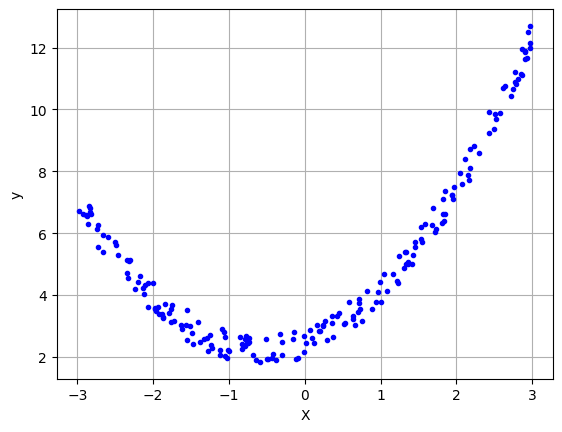

In [6]:
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.show()

In [7]:
X_train , X_test , y_train , y_test = train_test_split(X,y,random_state=2 , test_size=0.2)

In [8]:
lr = LinearRegression()

In [9]:
lr.fit(X_train,y_train)

LinearRegression()

In [10]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.4565023554569022

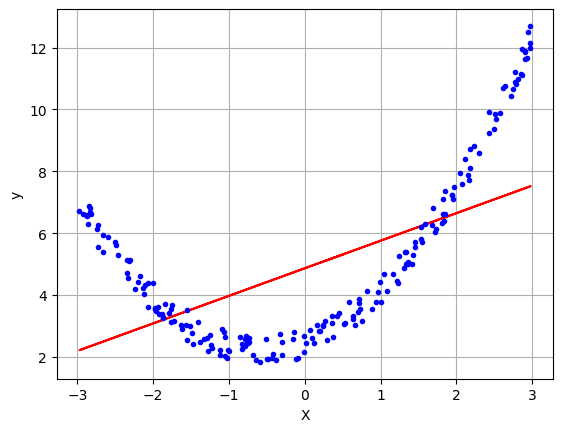

In [11]:
plt.plot(X_train , lr.predict(X_train), color='r')
plt.plot(X,y,"b.")
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.show()

In [14]:
poly = PolynomialFeatures(degree=2 , include_bias=False)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.fit_transform(X_test)

In [15]:
print(X_train[0])
print(X_train_trans[0])

[0.51556464]
[0.51556464 0.26580689]


In [16]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [17]:
y_pred = lr.predict(X_test_trans)
r2_score(y_test,y_pred)

0.992897416057343

In [18]:
print(lr.coef_)
print(lr.intercept_)

[[0.87416986 0.80081332]]
[2.49104291]


In [19]:
X_new = np.linspace(-3,3,100).reshape(100,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

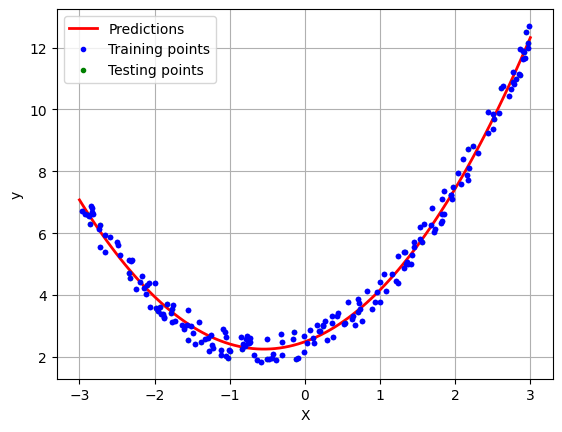

In [23]:
plt.plot(X_new,y_new,color='r' , linewidth=2 , label="Predictions")
plt.plot(X_train , y_train , "b." ,label="Training points")
plt.plot(X_test ,y_test , "g." , label="Testing points")
plt.plot(X,y,"b.")
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

In [24]:
def polynomial_regression(degree):
  X_new = np.linspace(-3,3,100).reshape(100,1)
  X_new_poly = poly.transform(X_new)

  polybig_features = PolynomialFeatures(degree=degree , include_bias=False)
  std_scaler = StandardScaler()
  lin_reg = LinearRegression()

  polynomial_regression = Pipeline([
    ("poly_features",polybig_features),
    ("std_scaler",std_scaler),
    ("lin_reg",lin_reg),
  ])
  polynomial_regression.fit(X,y)
  y_newbig = polynomial_regression.predict(X_new)
  plt.plot(X_new,y_newbig , 'r' ,label='Degree' + str(degree) ,linewidth=2)
  plt.plot(X_train , y_train , "b." ,label="Training points")
  plt.plot(X_test ,y_test , "g." , label="Testing points")
  plt.plot(X,y,"b.")
  plt.xlabel("X")
  plt.ylabel("y")
  plt.axis([-3,3,0,10])
  plt.grid(True)
  plt.legend(loc="upper left")
  plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1120: RuntimeWarning: overflow encountered in square
  temp **= 2
/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


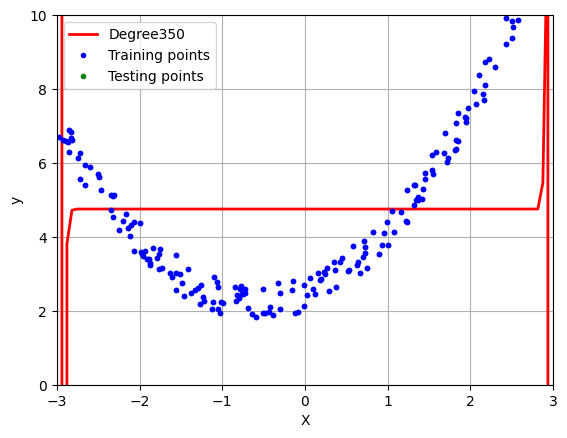

In [37]:
polynomial_regression(350)

In [38]:
# 3D Polynomial Regression :-
x = 7*np.random.rand(100,1) - 2.8
y = 7*np.random.rand(100,1) - 2.8

z = x**2 + y**2 +0.2*x + 0.2*y + 0.1*x*y +2 +np.random.randn(100,1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy +2

In [39]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df ,x=x.ravel(),y=y.ravel(), z=z.ravel())
fig.show()

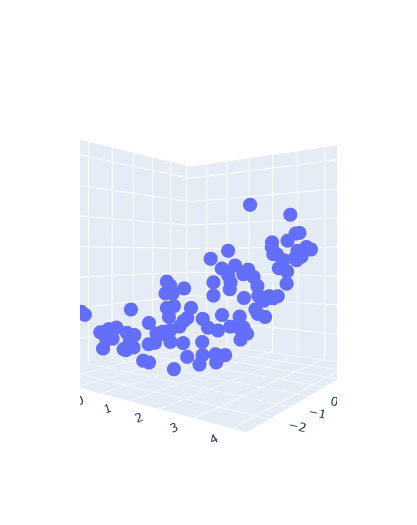

In [40]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min() , x.max() , 10)
y_input = np.linspace(y.min() , y.max() , 10)
xGrid , yGrid = np.meshgrid(x_input , y_input)

final = np.vstack((xGrid.ravel() , yGrid.ravel())).T
z_final = lr.predict(final).reshape(10,10)

In [41]:
import plotly.graph_objects as go
fig = go.Figure(data=[go.Surface(z=z_final,x=x_input,y=y_input)])
fig.add_trace(go.Scatter3d(x=x.ravel(),y=y.ravel(),z=z.ravel(),mode='markers'))
fig.show()

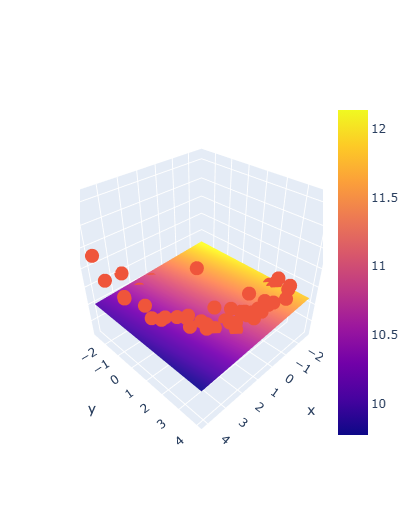

In [42]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [55]:
poly = PolynomialFeatures(degree=30)
X_multi_trans = poly.fit_transform(X_multi)

In [56]:
print("Input",poly.n_features_in_)
print("Output" , X_multi_trans.shape[1])
print("Powers\n" , poly.powers_)

Input 2
Output 496
Powers
 [[ 0  0]
 [ 1  0]
 [ 0  1]
 [ 2  0]
 [ 1  1]
 [ 0  2]
 [ 3  0]
 [ 2  1]
 [ 1  2]
 [ 0  3]
 [ 4  0]
 [ 3  1]
 [ 2  2]
 [ 1  3]
 [ 0  4]
 [ 5  0]
 [ 4  1]
 [ 3  2]
 [ 2  3]
 [ 1  4]
 [ 0  5]
 [ 6  0]
 [ 5  1]
 [ 4  2]
 [ 3  3]
 [ 2  4]
 [ 1  5]
 [ 0  6]
 [ 7  0]
 [ 6  1]
 [ 5  2]
 [ 4  3]
 [ 3  4]
 [ 2  5]
 [ 1  6]
 [ 0  7]
 [ 8  0]
 [ 7  1]
 [ 6  2]
 [ 5  3]
 [ 4  4]
 [ 3  5]
 [ 2  6]
 [ 1  7]
 [ 0  8]
 [ 9  0]
 [ 8  1]
 [ 7  2]
 [ 6  3]
 [ 5  4]
 [ 4  5]
 [ 3  6]
 [ 2  7]
 [ 1  8]
 [ 0  9]
 [10  0]
 [ 9  1]
 [ 8  2]
 [ 7  3]
 [ 6  4]
 [ 5  5]
 [ 4  6]
 [ 3  7]
 [ 2  8]
 [ 1  9]
 [ 0 10]
 [11  0]
 [10  1]
 [ 9  2]
 [ 8  3]
 [ 7  4]
 [ 6  5]
 [ 5  6]
 [ 4  7]
 [ 3  8]
 [ 2  9]
 [ 1 10]
 [ 0 11]
 [12  0]
 [11  1]
 [10  2]
 [ 9  3]
 [ 8  4]
 [ 7  5]
 [ 6  6]
 [ 5  7]
 [ 4  8]
 [ 3  9]
 [ 2 10]
 [ 1 11]
 [ 0 12]
 [13  0]
 [12  1]
 [11  2]
 [10  3]
 [ 9  4]
 [ 8  5]
 [ 7  6]
 [ 6  7]
 [ 5  8]
 [ 4  9]
 [ 3 10]
 [ 2 11]
 [ 1 12]
 [ 0 13]
 [14  0]
 [13  1]
 [12  2]
 

In [57]:
X_multi_trans.shape

(100, 496)

In [58]:
lr = LinearRegression()
lr.fit(X_multi_trans,y)

LinearRegression()

In [59]:
X_test_multi = poly.transform(final)

In [60]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [61]:
fig = px.scatter_3d(x=x.ravel() , y=y.ravel(), z=z.ravel())
fig.add_trace(go.Surface(x=x_input , y=y_input , z = z_final))
fig.update_layout(scene=dict(zaxis = dict(range=[0,35])))
fig.show()

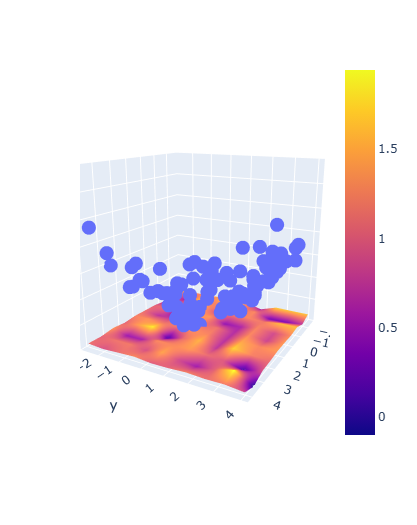